In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [37]:
df = pd.read_csv('mnist_train.csv')

In [38]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
df.shape

(60000, 785)

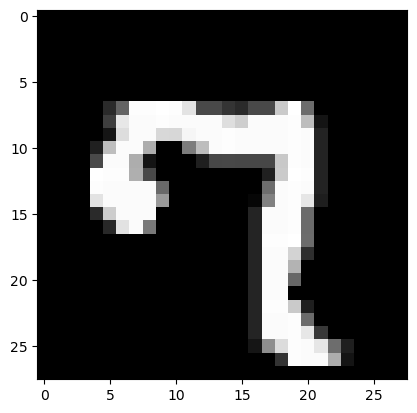

In [40]:
plt.imshow(df.iloc[35450,1:785].values.reshape(28, 28), cmap='gray')

In [41]:
x = df.iloc[:,1:785]
y = df.iloc[:,0]

In [42]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [43]:
x_train.shape

(48000, 784)

In [44]:
from sklearn.neighbors import KNeighborsClassifier

In [45]:
knn=KNeighborsClassifier()

In [46]:
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [47]:
y_pred=knn.predict(x_test)

In [48]:
y_pred

array([7, 3, 8, ..., 9, 7, 2], dtype=int64)

In [49]:
from sklearn.metrics import accuracy_score

In [50]:
accuracy_score(y_test, y_pred)

0.9715

In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
scalar = StandardScaler()

In [53]:
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

In [54]:
from sklearn.decomposition import PCA
pca = PCA(n_components=500)

In [61]:
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.transform(x_test)

In [56]:
x_train_trf.shape

(48000, 500)

In [57]:
knn = KNeighborsClassifier()

In [62]:
knn.fit(x_train_trf, y_train)

KNeighborsClassifier()

In [63]:
y_pred = knn.predict(x_test_trf)

In [64]:
accuracy_score(y_test, y_pred)


0.9466666666666667

In [65]:
max = 0
for i in range(1, 785):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_trf, y_train)
    y_pred = knn.predict(x_test_trf)
    acc = accuracy_score(y_test, y_pred)
    if acc > max:
        max = acc
print(max)  

KeyboardInterrupt: 

In [66]:
pca = PCA(n_components=2)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.fit_transform(x_test)

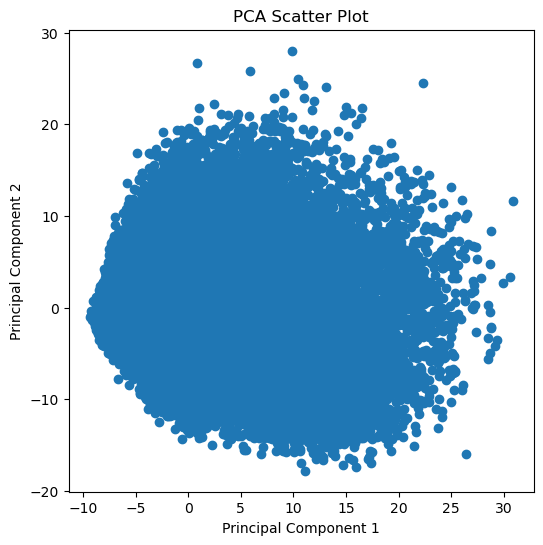

In [67]:

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(x_train_trf[:, 0], x_train_trf[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot")
plt.show()

In [68]:

pca = PCA(n_components=3)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.fit_transform(x_test)

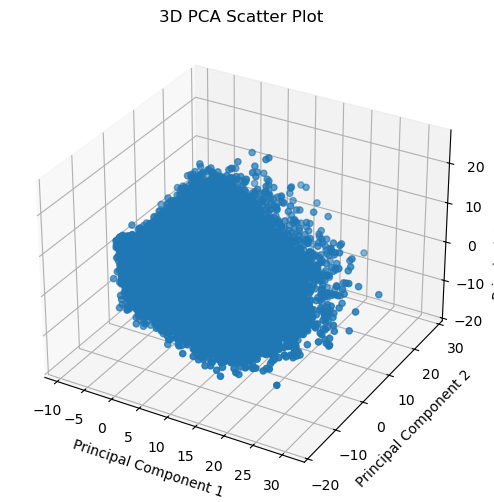

In [69]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    x_train_trf[:, 0],  # PC1
    x_train_trf[:, 1],  # PC2
    x_train_trf[:, 2]   # PC3
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA Scatter Plot")

plt.show()

In [ ]:
pca.explained_variance_
#eigen values

array([122.17391103,  42.62464714,  39.65781987])

In [ ]:
pca.components_
#eigen vectors

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.]])

In [ ]:
pca.components_.shape
#

In [72]:
pca.explained_variance_ratio_

array([0.13302617, 0.04641084, 0.04318048])

In [73]:

pca = PCA(n_components=None)
x_train_trf = pca.fit_transform(x_train)
x_test_trf = pca.fit_transform(x_test)

In [74]:
pca.explained_variance_


array([1.22173911e+02, 4.26246471e+01, 3.96578199e+01, 3.95912659e+01,
       2.85462034e+01, 2.71862899e+01, 2.21089743e+01, 2.06116089e+01,
       1.85988898e+01, 1.75264102e+01, 1.55616298e+01, 1.35112792e+01,
       1.24399341e+01, 1.10204245e+01, 1.02897162e+01, 9.75558804e+00,
       8.46393262e+00, 7.95625188e+00, 7.78795215e+00, 7.61383965e+00,
       7.31758508e+00, 7.05655407e+00, 6.91514660e+00, 6.70040249e+00,
       6.45021662e+00, 6.24937450e+00, 6.03066520e+00, 5.94836041e+00,
       5.79513897e+00, 5.47938574e+00, 5.43956264e+00, 5.13296147e+00,
       5.01274464e+00, 4.89036063e+00, 4.83711710e+00, 4.62808139e+00,
       4.52634796e+00, 4.39511338e+00, 4.32591715e+00, 4.26987200e+00,
       4.21753345e+00, 4.06549050e+00, 4.01877802e+00, 3.96796557e+00,
       3.84112764e+00, 3.81614628e+00, 3.77410057e+00, 3.69848743e+00,
       3.66842766e+00, 3.60264993e+00, 3.58105640e+00, 3.47421490e+00,
       3.33951733e+00, 3.26065790e+00, 3.20340679e+00, 3.17662937e+00,
      

In [75]:
pca.explained_variance_ratio_

array([1.33026175e-01, 4.64108394e-02, 4.31804797e-02, 4.31080139e-02,
       3.10818588e-02, 2.96011491e-02, 2.40728340e-02, 2.24424631e-02,
       2.02509614e-02, 1.90832174e-02, 1.69439127e-02, 1.47114370e-02,
       1.35449282e-02, 1.19993287e-02, 1.12037143e-02, 1.06221414e-02,
       9.21575295e-03, 8.66297677e-03, 8.47972759e-03, 8.29014931e-03,
       7.96757953e-03, 7.68336208e-03, 7.52939390e-03, 7.29557486e-03,
       7.02316588e-03, 6.80448369e-03, 6.56634724e-03, 6.47673161e-03,
       6.30990007e-03, 5.96609963e-03, 5.92273919e-03, 5.58890375e-03,
       5.45800850e-03, 5.32475357e-03, 5.26678061e-03, 5.03917702e-03,
       4.92840697e-03, 4.78551530e-03, 4.71017262e-03, 4.64914918e-03,
       4.59216159e-03, 4.42661322e-03, 4.37575145e-03, 4.32042551e-03,
       4.18232102e-03, 4.15512067e-03, 4.10934018e-03, 4.02701061e-03,
       3.99428074e-03, 3.92266021e-03, 3.89914860e-03, 3.78281676e-03,
       3.63615450e-03, 3.55029027e-03, 3.48795375e-03, 3.45879779e-03,
      

In [77]:
np.cumsum(pca.explained_variance_ratio_)

array([0.13302617, 0.17943701, 0.22261749, 0.26572551, 0.29680737,
       0.32640852, 0.35048135, 0.37292381, 0.39317477, 0.41225799,
       0.4292019 , 0.44391334, 0.45745827, 0.4694576 , 0.48066131,
       0.49128345, 0.50049921, 0.50916218, 0.51764191, 0.52593206,
       0.53389964, 0.541583  , 0.5491124 , 0.55640797, 0.56343114,
       0.57023562, 0.57680197, 0.5832787 , 0.5895886 , 0.5955547 ,
       0.60147744, 0.60706634, 0.61252435, 0.6178491 , 0.62311588,
       0.62815506, 0.63308347, 0.63786898, 0.64257916, 0.64722831,
       0.65182047, 0.65624708, 0.66062283, 0.66494326, 0.66912558,
       0.6732807 , 0.67739004, 0.68141705, 0.68541133, 0.68933399,
       0.69323314, 0.69701596, 0.70065211, 0.7042024 , 0.70769035,
       0.71114915, 0.71455904, 0.71792394, 0.72121614, 0.72443044,
       0.72760631, 0.73071944, 0.73374786, 0.73673245, 0.73971634,
       0.74265706, 0.74554882, 0.74838903, 0.75121222, 0.75398232,
       0.75671518, 0.75938852, 0.76199938, 0.76457504, 0.76710

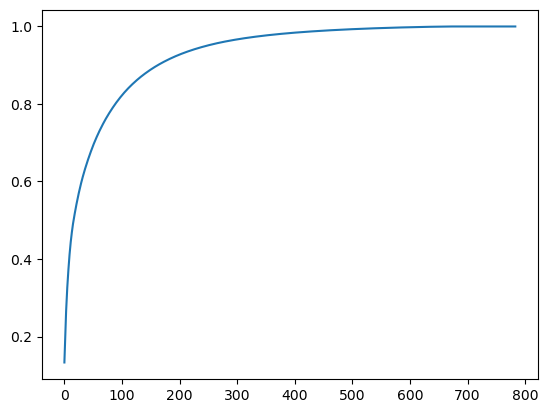

In [78]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [ ]:
#90 percent variance is explained by 154 components